# Python Practice Questions - Session 2 (Advanced Matplotlib)

## Topics Covered

- Colored Scatter Plot
- alpha
- figsize
- annotate()
- axhline()
- axvline()
- plt.subplots()
- fig.add_subplot()
- 3D Scatter Plot
- 3D Line Plot
- 3D Surface Plot
- Contour Plot
- Contour Filled Plot

---

# Dataset

Use the following datasets:

- `iris.csv`
- `batter.csv`
- `IPL_Ball_by_Ball_2008_2022.csv`

---

# Instructions

- Solve all questions in Jupyter Notebook.
- Use meaningful variable names.
- Add comments wherever necessary.
- Use only **Pandas**, **NumPy**, and **Matplotlib**.
- Every graph should have a proper title and axis labels.
- Do not modify the original dataset unless explicitly instructed.
- Wherever required, use `plt.figure()` or `plt.subplots()` appropriately.

# Question 1 — Colored Scatter Plot

## Dataset

`iris.csv`

## Problem Statement

Load the dataset into a DataFrame named `iris`.

### Requirements

1. Create a copy of the dataset.
2. Convert the species names into numeric values:
   - Setosa → 0
   - Versicolor → 1
   - Virginica → 2
3. Create a scatter plot:
   - X-axis → Petal Length
   - Y-axis → Petal Width
4. Color each point according to its species.
5. Set transparency (`alpha`) to `0.7`.
6. Set figure size to `(10,6)`.
7. Add:
   - Title
   - Axis labels
   - Colorbar
8. Which species appears most clearly separated from the others?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
iris = pd.read_csv('iris.csv')
iris.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
81,82,5.5,2.4,3.7,1.0,Iris-versicolor
7,8,5.0,3.4,1.5,0.2,Iris-setosa
147,148,6.5,3.0,5.2,2.0,Iris-virginica
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
110,111,6.5,3.2,5.1,2.0,Iris-virginica


In [3]:
iris['Species'] = iris['Species'].replace({'Iris-setosa':0, 'Iris-versicolor':1,'Iris-virginica':2})
iris.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
58,59,6.6,2.9,4.6,1.3,1
50,51,7.0,3.2,4.7,1.4,1
91,92,6.1,3.0,4.6,1.4,1
121,122,5.6,2.8,4.9,2.0,2
110,111,6.5,3.2,5.1,2.0,2


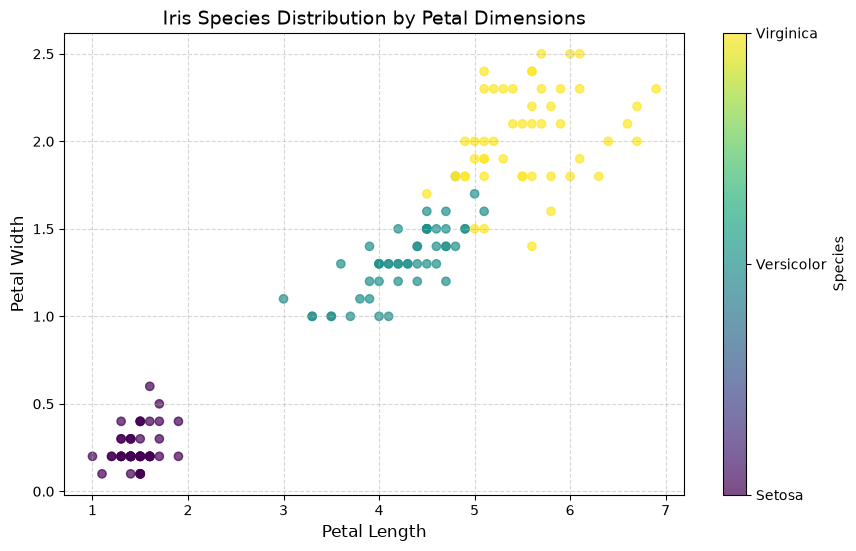

In [4]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(iris['PetalLengthCm'],iris['PetalWidthCm'],alpha=0.7,c=iris['Species'],cmap='viridis')
plt.title("Iris Species Distribution by Petal Dimensions", fontsize=14)
plt.xlabel("Petal Length", fontsize=12)
plt.ylabel("Petal Width", fontsize=12)
cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.set_ticklabels(["Setosa", "Versicolor", "Virginica"])
cbar.set_label("Species")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Question 2 — Scatter Plot with Annotations

## Dataset

`batter.csv`

## Problem Statement

Load the dataset into a DataFrame named `batter`.

### Requirements

1. Select the top 30 batters based on total runs.
2. Create a scatter plot:
   - X-axis → Average
   - Y-axis → Strike Rate
3. Make bubble size proportional to total runs.
4. Annotate every point using the batter's name.
5. Increase figure size so labels become readable.
6. Add title, labels and grid.
7. Identify:
   - Batter with highest strike rate.
   - Batter with highest batting average.

In [5]:
batter = pd.read_csv('batter.csv')
batter

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
...,...,...,...,...
600,C Nanda,0,0.000000,0.000000
601,Akash Deep,0,0.000000,0.000000
602,S Ladda,0,0.000000,0.000000
603,V Pratap Singh,0,0.000000,0.000000


In [6]:
top_30 = batter.sort_values(by='runs',ascending=False).head(30)
top_30

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
5,AB de Villiers,5181,39.853846,148.580442
6,CH Gayle,4997,39.658730,142.121729
7,MS Dhoni,4978,39.196850,130.931089
8,RV Uthappa,4954,27.522222,126.152279
9,KD Karthik,4377,26.852761,129.267572


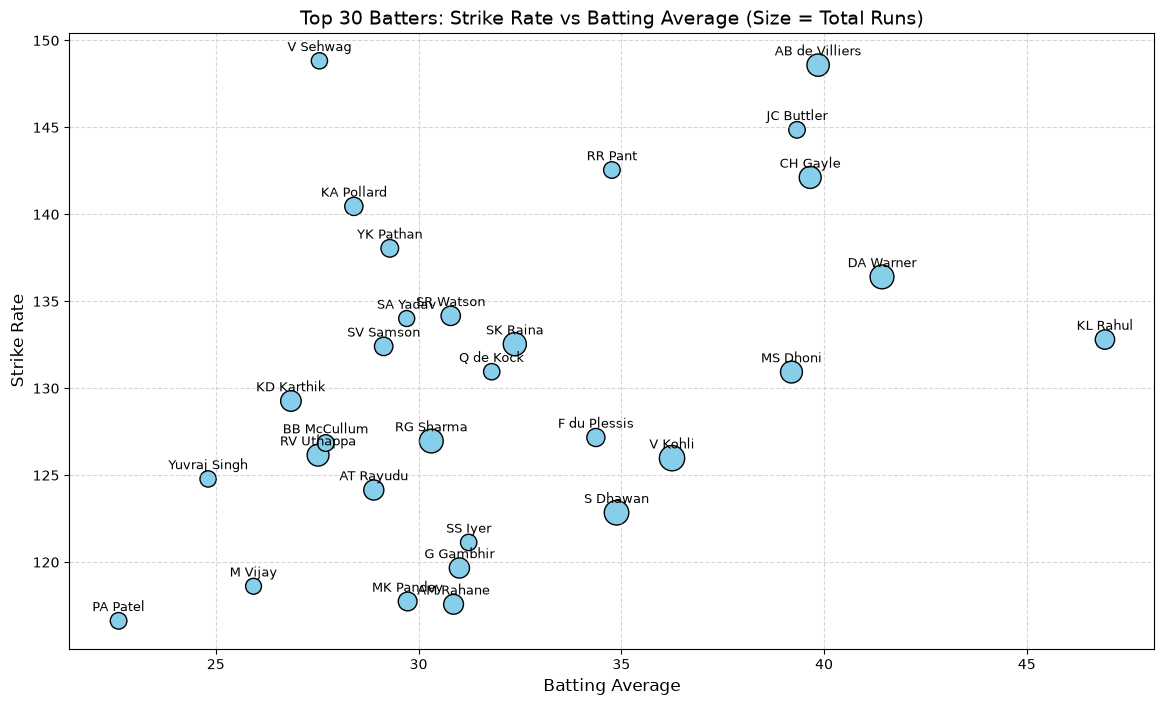

Batter with highest strike rate: V Sehwag (148.82705946535734)
Batter with highest batting average: KL Rahul (46.9277108433735)


In [7]:
plt.figure(figsize=(14,8))
plt.scatter(top_30['avg'],top_30['strike_rate'],s=top_30['runs']*0.05,c="skyblue",edgecolors='black')
for idx, row in top_30.iterrows():
    plt.annotate(
        row['batter'],
        (row['avg'], row['strike_rate']),
        textcoords='offset points',
        xytext=(0,7),
        ha='center',
        fontsize=9
    )
plt.title(
    "Top 30 Batters: Strike Rate vs Batting Average (Size = Total Runs)",
    fontsize=14,
)
plt.xlabel("Batting Average", fontsize=12)
plt.ylabel("Strike Rate", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()
highest_sr_batter = top_30.loc[top_30["strike_rate"].idxmax()]
highest_avg_batter = top_30.loc[top_30["avg"].idxmax()]

print(
    f"Batter with highest strike rate: {highest_sr_batter['batter']} ({highest_sr_batter['strike_rate']})"
)
print(
    f"Batter with highest batting average: {highest_avg_batter['batter']} ({highest_avg_batter['avg']})"
)

# Question 3 — Scatter Plot with Reference Lines

## Dataset

`batter.csv`

## Problem Statement

Load the dataset into a DataFrame named `batter`.

### Requirements

1. Select the top 50 batters by runs.
2. Create a scatter plot:
   - X-axis → Average
   - Y-axis → Strike Rate
3. Draw:
   - Vertical line at Average = 30
   - Horizontal line at Strike Rate = 130
4. Use different colors for both lines.
5. Add title, labels and grid.
6. Determine:
   - Number of batters in the top-right quadrant.
   - Number of batters below both thresholds.

In [8]:
batter = pd.read_csv('batter.csv')
batter

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
...,...,...,...,...
600,C Nanda,0,0.000000,0.000000
601,Akash Deep,0,0.000000,0.000000
602,S Ladda,0,0.000000,0.000000
603,V Pratap Singh,0,0.000000,0.000000


In [9]:
top_50 = batter.sort_values(by='runs',ascending=False).head(50)
top_50

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
5,AB de Villiers,5181,39.853846,148.580442
6,CH Gayle,4997,39.658730,142.121729
7,MS Dhoni,4978,39.196850,130.931089
8,RV Uthappa,4954,27.522222,126.152279
9,KD Karthik,4377,26.852761,129.267572


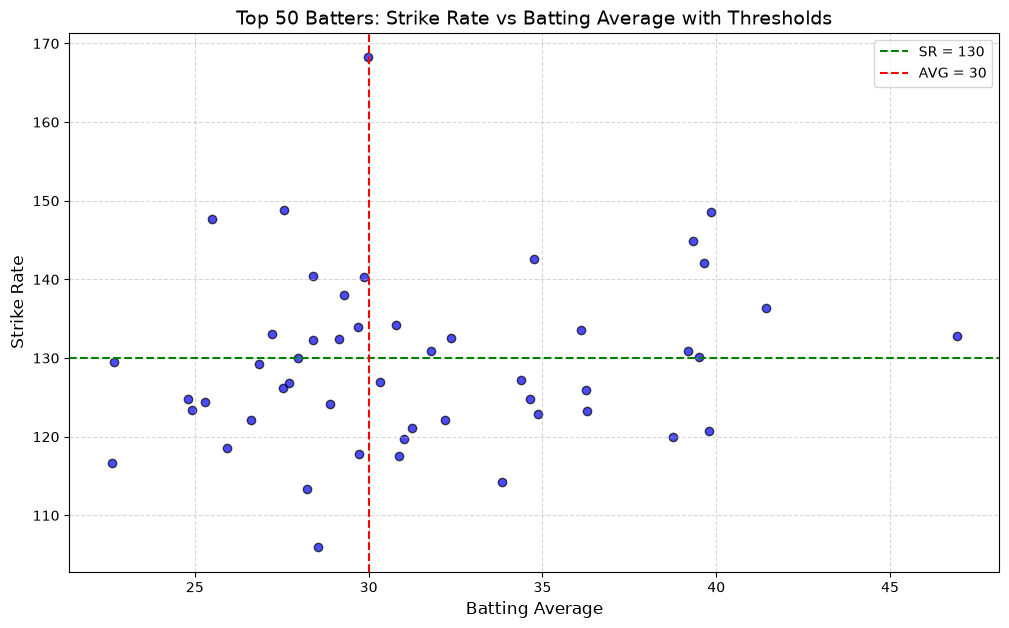

Batters in Top-Right Quadrant : 12
Batters Below Both Thresholds : 14


In [10]:
plt.figure(figsize=(12,7))
plt.scatter(top_50['avg'],top_50['strike_rate'],color="blue",alpha=0.7,edgecolors='black')
plt.axhline(130, color='green', linestyle='--', linewidth=1.5, label="SR = 130")
plt.axvline(30, color='red', linestyle='--', linewidth=1.5, label="AVG = 30")
plt.title(
    "Top 50 Batters: Strike Rate vs Batting Average with Thresholds",
    fontsize=14,
)
plt.xlabel("Batting Average", fontsize=12)
plt.ylabel("Strike Rate", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()
top_right = top_50[
    (top_50["avg"] > 30) &
    (top_50["strike_rate"] > 130)
].shape[0]
bottom_left = top_50[
    (top_50["avg"] < 30) &
    (top_50["strike_rate"] < 130)
].shape[0]
print("Batters in Top-Right Quadrant :", top_right)
print("Batters Below Both Thresholds :", bottom_left)

# Question 4 — Creating Subplots

## Dataset

`batter.csv`

## Problem Statement

Load the dataset into a DataFrame named `batter`.

### Requirements

Create a figure with **2 rows and 2 columns** using `plt.subplots()`.

Display the following graphs:

1. Scatter Plot
   - Average vs Strike Rate

2. Histogram
   - Average

3. Histogram
   - Strike Rate

4. Bar Chart
   - Top 10 run scorers

For every subplot:

- Add title.
- Add axis labels.
- Turn grid ON where appropriate.
- Adjust figure size for better readability.


In [11]:
batter = pd.read_csv('batter.csv')
batter

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
...,...,...,...,...
600,C Nanda,0,0.000000,0.000000
601,Akash Deep,0,0.000000,0.000000
602,S Ladda,0,0.000000,0.000000
603,V Pratap Singh,0,0.000000,0.000000


In [12]:
top_10 = batter.sort_values(by='runs',ascending=False).head(10)
top_10

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
5,AB de Villiers,5181,39.853846,148.580442
6,CH Gayle,4997,39.658730,142.121729
7,MS Dhoni,4978,39.196850,130.931089
8,RV Uthappa,4954,27.522222,126.152279
9,KD Karthik,4377,26.852761,129.267572


In [13]:
top_50 = batter.sort_values(by='runs',ascending=False).head(50)
top_50

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
5,AB de Villiers,5181,39.853846,148.580442
6,CH Gayle,4997,39.658730,142.121729
7,MS Dhoni,4978,39.196850,130.931089
8,RV Uthappa,4954,27.522222,126.152279
9,KD Karthik,4377,26.852761,129.267572


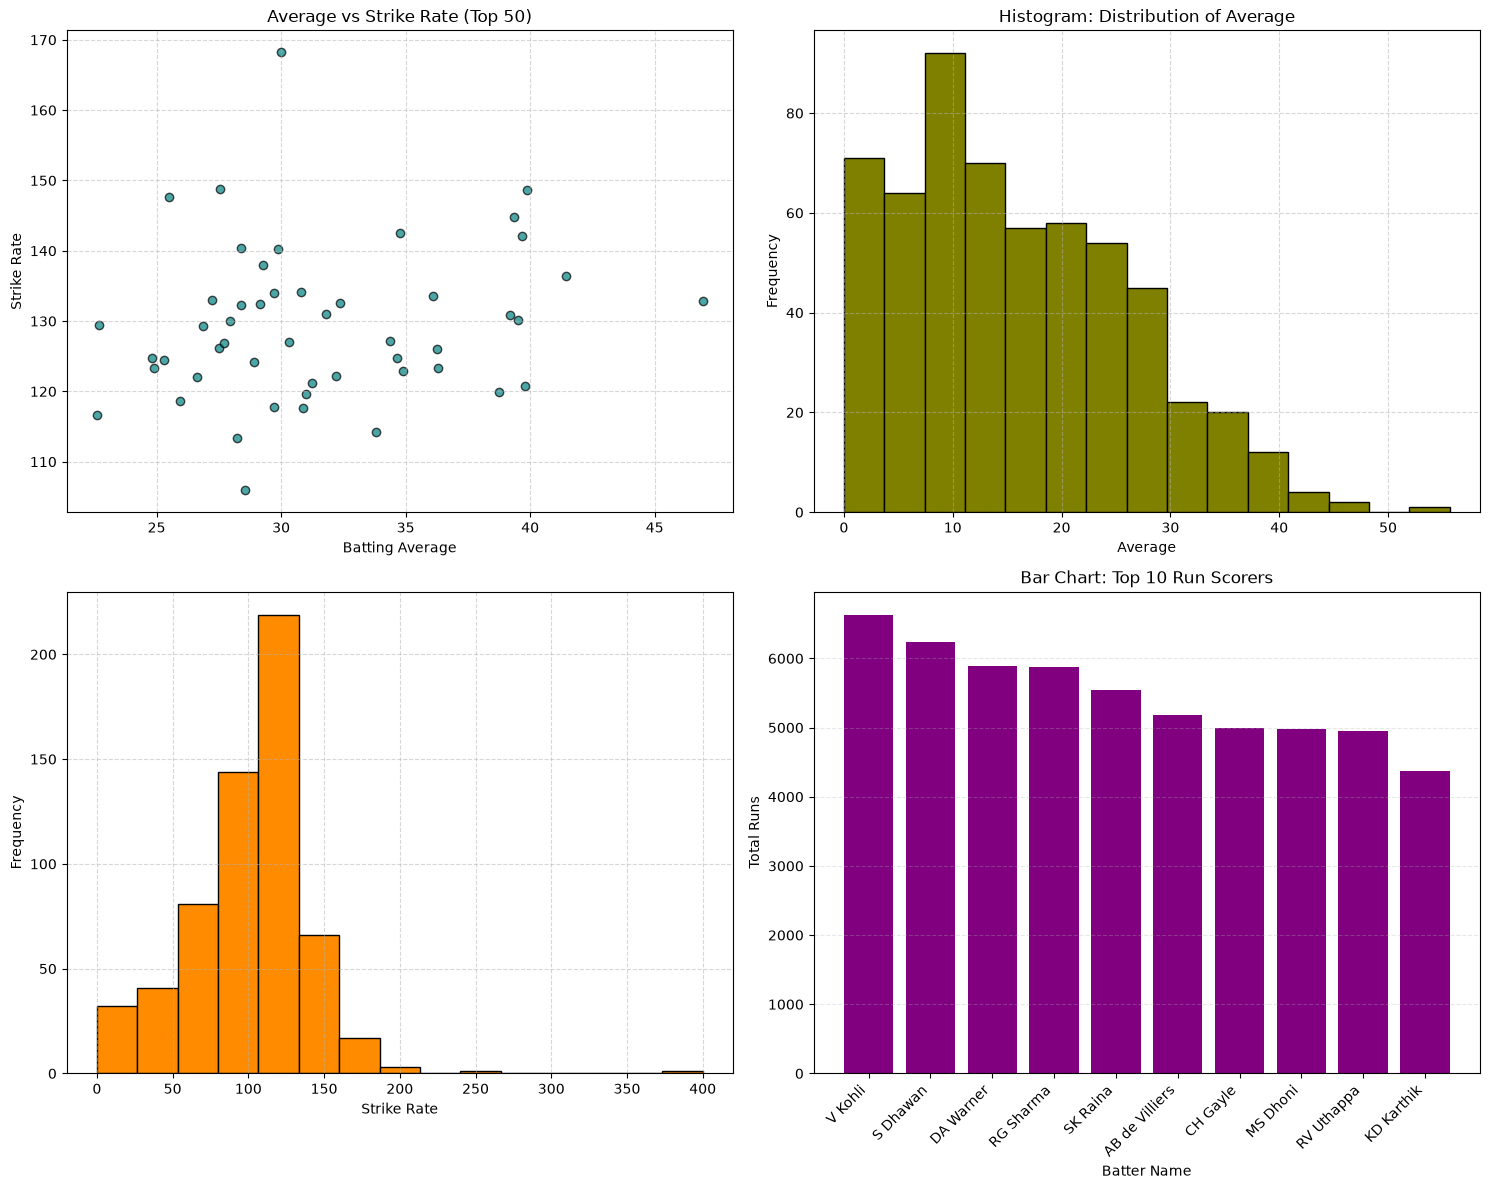

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,12))

axes[0,0].scatter(top_50['avg'],top_50['strike_rate'], color='teal', alpha=0.7, edgecolor='black')
axes[0, 0].set_title("Average vs Strike Rate (Top 50)", fontsize=12)
axes[0, 0].set_xlabel("Batting Average")
axes[0, 0].set_ylabel("Strike Rate")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

axes[0,1].hist(batter['avg'].dropna(), bins=15, color='olive', edgecolor='black')
axes[0, 1].set_title("Histogram: Distribution of Average", fontsize=12)
axes[0, 1].set_xlabel("Average")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

axes[1,0].hist(batter['strike_rate'].dropna(), bins=15, color='darkorange', edgecolor='black')
axes[1, 0].set_xlabel("Strike Rate")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

axes[1,1].bar(top_10['batter'],top_10['runs'], color='purple')
axes[1, 1].set_title("Bar Chart: Top 10 Run Scorers", fontsize=12)
axes[1, 1].set_xlabel("Batter Name")
axes[1, 1].set_ylabel("Total Runs")
axes[1, 1].set_xticklabels(
    top_10["batter"], rotation=45, ha="right"
) 
axes[1, 1].grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Question 5 — Subplots with Shared X-axis

## Dataset

`batter.csv`

## Problem Statement

Load the dataset into a DataFrame named `batter`.

### Requirements

1. Create two vertically stacked scatter plots using `plt.subplots()`.
2. Share the X-axis.
3. First graph:
   - Average vs Strike Rate
4. Second graph:
   - Average vs Runs
5. Add:
   - Separate titles
   - Axis labels
   - Grid
6. Increase figure size to `(12,8)`.


In [15]:
batter = pd.read_csv("batter.csv")
batter

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
...,...,...,...,...
600,C Nanda,0,0.000000,0.000000
601,Akash Deep,0,0.000000,0.000000
602,S Ladda,0,0.000000,0.000000
603,V Pratap Singh,0,0.000000,0.000000


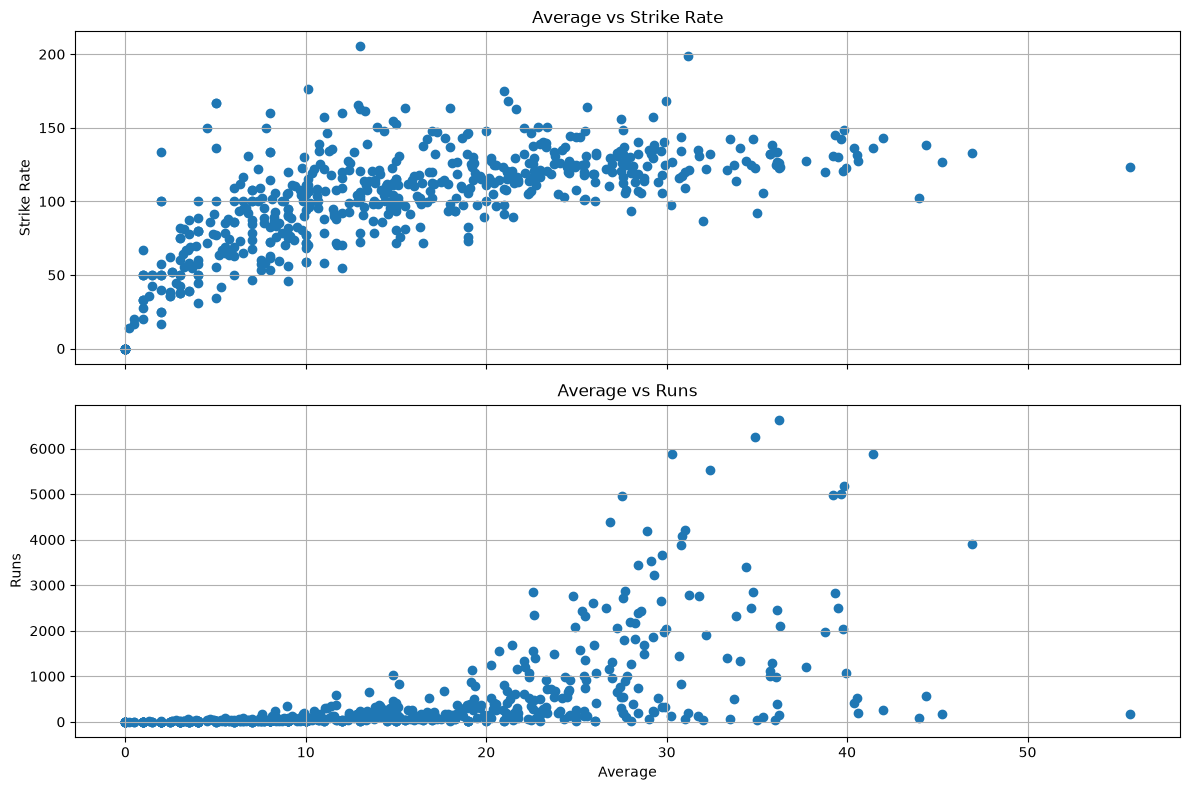

In [16]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(12,8))

ax[0].scatter(batter["avg"], batter["strike_rate"])
ax[0].set_title("Average vs Strike Rate")
ax[0].set_ylabel("Strike Rate")
ax[0].grid(True)

ax[1].scatter(batter['avg'], batter['runs'])
ax[1].set_title("Average vs Runs")
ax[1].set_xlabel("Average")
ax[1].set_ylabel("Runs")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Question 6 — Using fig.add_subplot()

## Dataset

`batter.csv`

## Problem Statement

Load the dataset into a DataFrame named `batter`.

### Requirements

Using `fig.add_subplot()`:

1. Create four subplots.
2. Plot:
   - Scatter Plot
   - Histogram
   - Bar Chart
   - Pie Chart (Top 5 run scorers)
3. Add appropriate titles.
4. Add axis labels wherever applicable.
5. Compare which visualization is most suitable for understanding player performance.

In [17]:
batter = pd.read_csv("batter.csv")
batter

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
...,...,...,...,...
600,C Nanda,0,0.000000,0.000000
601,Akash Deep,0,0.000000,0.000000
602,S Ladda,0,0.000000,0.000000
603,V Pratap Singh,0,0.000000,0.000000


In [18]:
top_5 = batter.sort_values("runs", ascending=False).head(5)
top_5

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312


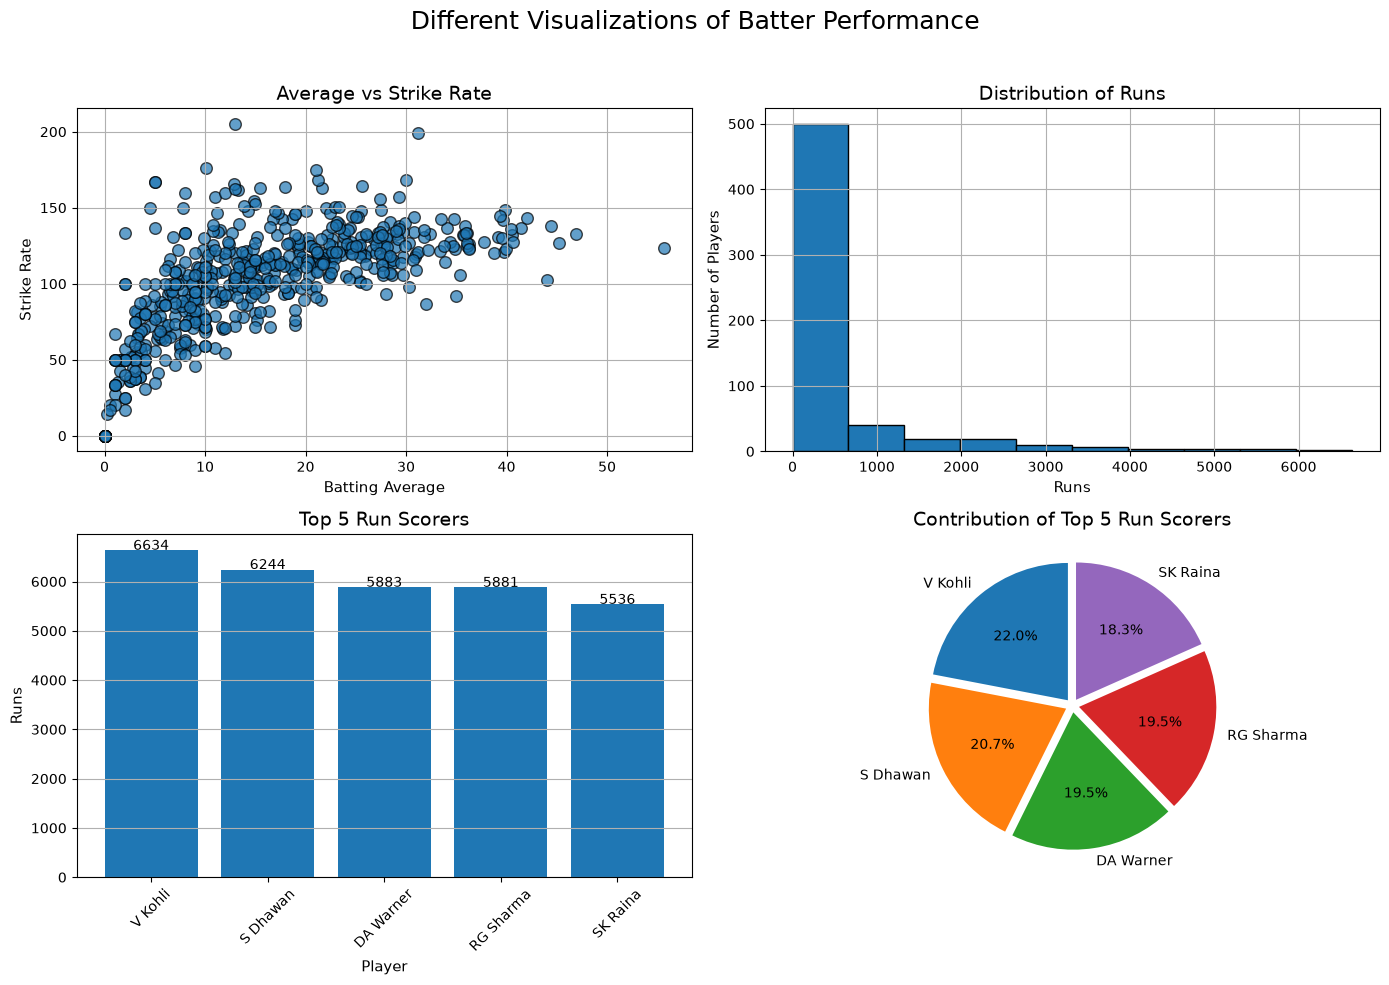

In [19]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Different Visualizations of Batter Performance", fontsize=18)

ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(batter['avg'], batter['strike_rate'], s=70, alpha=0.7, edgecolor='black')
ax1.set_title("Average vs Strike Rate", fontsize=14)
ax1.set_xlabel("Batting Average", fontsize=11)
ax1.set_ylabel("Strike Rate", fontsize=11)
ax1.grid(True)

ax2 = fig.add_subplot(2, 2, 2)

ax2.hist(
    batter["runs"],
    bins=10,
    edgecolor="black"
)

ax2.set_title("Distribution of Runs", fontsize=14)
ax2.set_xlabel("Runs", fontsize=11)
ax2.set_ylabel("Number of Players", fontsize=11)
ax2.grid(True)

ax3 = fig.add_subplot(2, 2, 3)

ax3.bar(
    top_5["batter"],
    top_5["runs"]
)

ax3.set_title("Top 5 Run Scorers", fontsize=14)
ax3.set_xlabel("Player", fontsize=11)
ax3.set_ylabel("Runs", fontsize=11)
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y")
for i, value in enumerate(top_5["runs"]):
    ax3.text(i, value + 10, str(value), ha="center", fontsize=10)

ax4 = fig.add_subplot(2, 2, 4)

ax4.pie(
    top_5["runs"],
    labels=top_5["batter"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0.05, 0.05, 0.05, 0.05]
)

ax4.set_title("Contribution of Top 5 Run Scorers", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Question 7 — 3D Scatter Plot

## Dataset

`batter.csv`

## Problem Statement

Load the dataset into a DataFrame named `batter`.

### Requirements

1. Create a 3D scatter plot.
2. Use:
   - X-axis → Runs
   - Y-axis → Average
   - Z-axis → Strike Rate
3. Set figure size `(10,8)`.
4. Add:
   - Title
   - X label
   - Y label
   - Z label
5. Use blue markers.
6. Which players appear to have both high average and high strike rate?


In [20]:
batter = pd.read_csv("batter.csv")
batter

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312
...,...,...,...,...
600,C Nanda,0,0.000000,0.000000
601,Akash Deep,0,0.000000,0.000000
602,S Ladda,0,0.000000,0.000000
603,V Pratap Singh,0,0.000000,0.000000


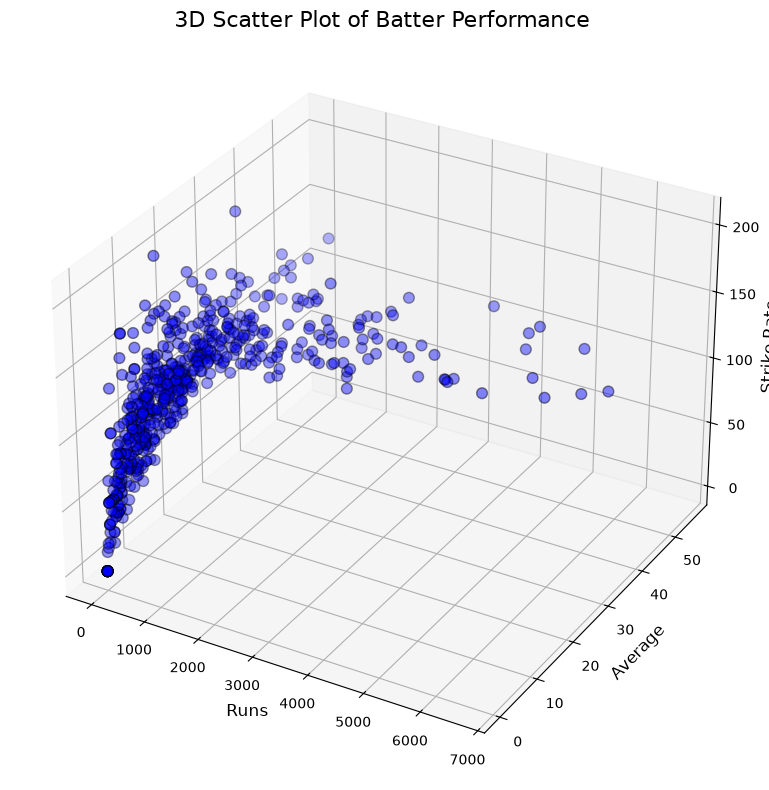

        batter  runs   avg  strike_rate
174  DP Conway   252  42.0   143.181818


In [21]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(batter['runs'],batter['avg'],batter['strike_rate'], color='blue', s=60, alpha = 0.7, edgecolor='black')
ax.set_title("3D Scatter Plot of Batter Performance", fontsize=16)
ax.set_xlabel("Runs", fontsize=12)
ax.set_ylabel("Average", fontsize=12)
ax.set_zlabel("Strike Rate", fontsize=12)

plt.tight_layout()
plt.show()

best_players = batter[
    (batter["avg"] >= 40) &
    (batter["strike_rate"] >= 140)
]

print(best_players[["batter", "runs", "avg", "strike_rate"]])

# Question 8 — 3D Line Plot

## Dataset

Create the required NumPy arrays.

## Problem Statement

Generate the following arrays:

- x = [0, 2, 4, 6, 8]
- y = [1, 3, 2, 5, 4]
- z = [2, 5, 3, 6, 7]

### Requirements

1. Create a 3D line plot.
2. Connect all points.
3. Add:
   - Title
   - Axis labels
4. Change line color.
5. Add markers at every point.

In [22]:
x = np.array([0, 2, 4, 6, 8])
y = np.array([1, 3, 2, 5, 4])
z = np.array([2, 5, 3, 6, 7])

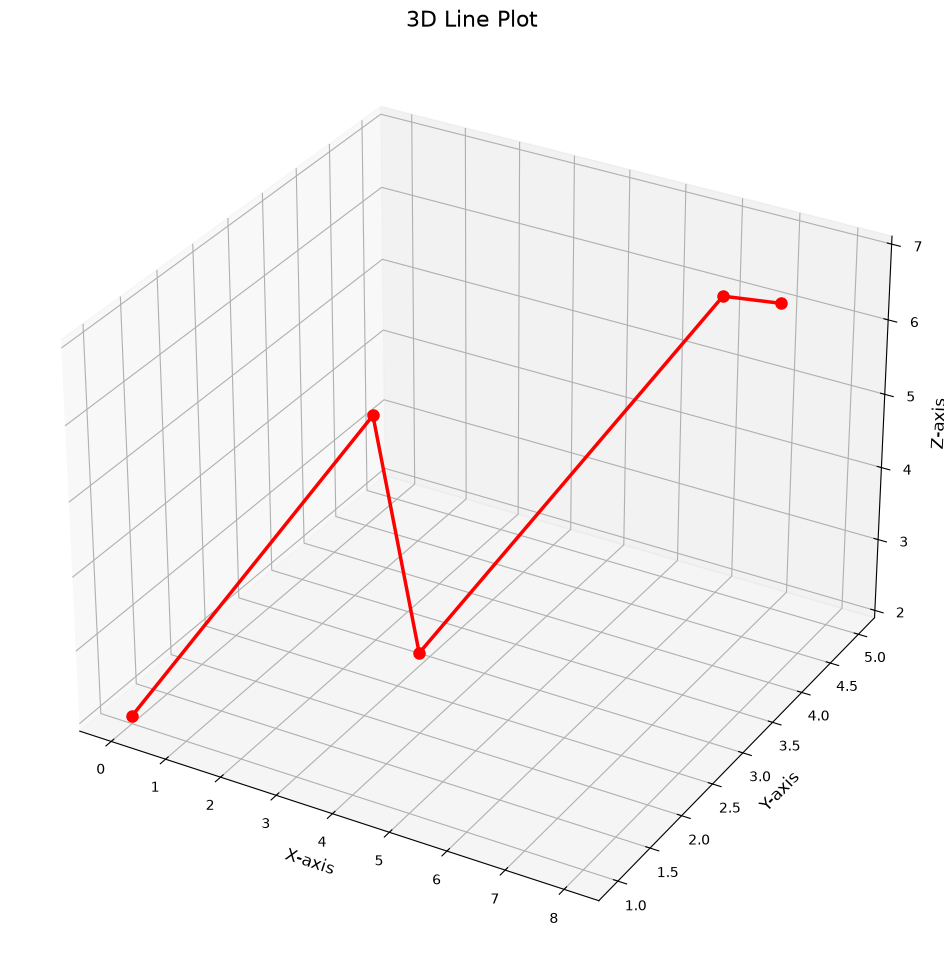

In [23]:
fig = plt.figure(figsize=(15, 12))

ax = fig.add_subplot(111, projection="3d")
ax.plot(
    x,
    y,
    z,
    color="red",       
    linewidth=2.5,  
    marker="o",       
    markersize=8,     
    linestyle="-"     
)
ax.set_title("3D Line Plot", fontsize=16)
ax.set_xlabel("X-axis", fontsize=12)
ax.set_ylabel("Y-axis", fontsize=12)
ax.set_zlabel("Z-axis", fontsize=12)

plt.show()

# Question 9 — 3D Surface Plot

## Dataset

No external dataset required.

## Problem Statement

Generate values for:

\[
z = x^2 + y^2
\]

using NumPy.

### Requirements

1. Generate x and y values from -10 to 10.
2. Create a meshgrid.
3. Compute z.
4. Plot a 3D surface.
5. Apply a colormap.
6. Add:
   - Title
   - Axis labels
   - Colorbar
7. Which region has the minimum value of z?

In [24]:
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)

In [25]:
X, Y = np.meshgrid(x, y)

In [26]:
Z = X**2 + Y**2
Z

array([[200.        , 196.00040812, 192.08244057, ..., 192.08244057,
        196.00040812, 200.        ],
       [196.00040812, 192.00081624, 188.08284869, ..., 188.08284869,
        192.00081624, 196.00040812],
       [192.08244057, 188.08284869, 184.16488113, ..., 184.16488113,
        188.08284869, 192.08244057],
       ...,
       [192.08244057, 188.08284869, 184.16488113, ..., 184.16488113,
        188.08284869, 192.08244057],
       [196.00040812, 192.00081624, 188.08284869, ..., 188.08284869,
        192.00081624, 196.00040812],
       [200.        , 196.00040812, 192.08244057, ..., 192.08244057,
        196.00040812, 200.        ]], shape=(100, 100))

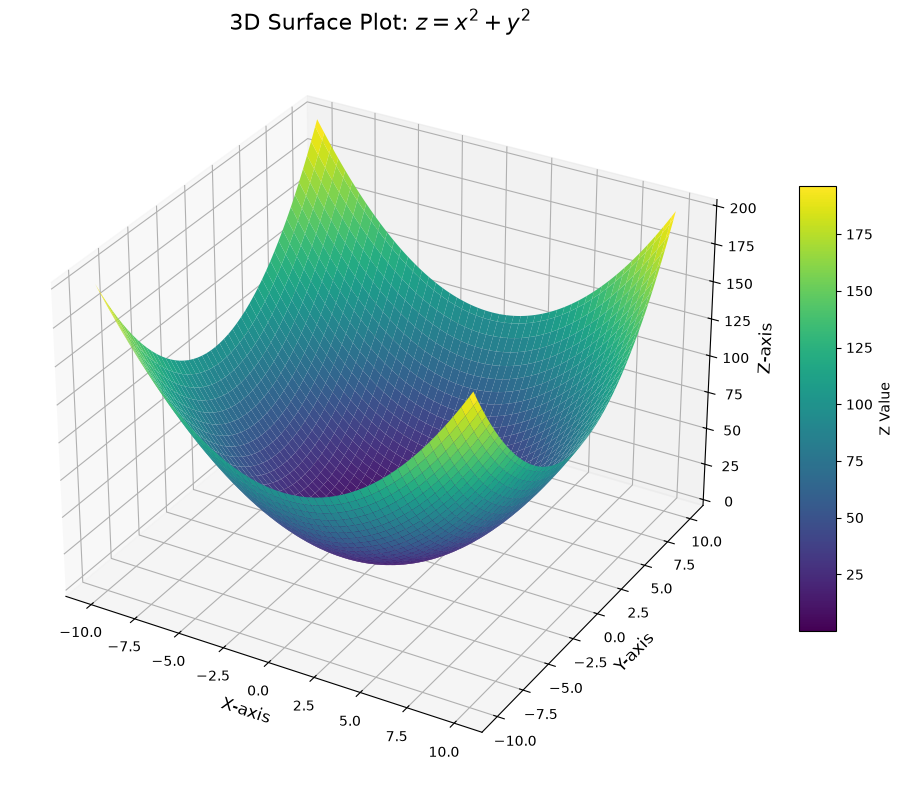

In [27]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="none"
)
ax.set_title("3D Surface Plot: $z = x^2 + y^2$", fontsize=16)
ax.set_xlabel("X-axis", fontsize=12)
ax.set_ylabel("Y-axis", fontsize=12)
ax.set_zlabel("Z-axis", fontsize=12)

fig.colorbar(surface, ax=ax, shrink=0.6, aspect=12, label="Z Value")

plt.tight_layout()
plt.show()

# Question 10 — Contour Visualization

## Dataset

No external dataset required.

## Problem Statement

Using the same function:

\[
z = \sin(x) + \cos(y)
\]

### Requirements

1. Generate x and y values.
2. Create a meshgrid.
3. Compute z.
4. Create:
   - Contour Plot
   - Filled Contour Plot
5. Display both graphs using subplots.
6. Add:
   - Titles
   - Colorbar
7. Compare both visualizations and explain:
   - Which one makes peaks and valleys easier to identify?
   - Why?


In [28]:
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)

In [29]:
X, Y = np.meshgrid(x, y)
X

array([[-5.        , -4.94974874, -4.89949749, ...,  4.89949749,
         4.94974874,  5.        ],
       [-5.        , -4.94974874, -4.89949749, ...,  4.89949749,
         4.94974874,  5.        ],
       [-5.        , -4.94974874, -4.89949749, ...,  4.89949749,
         4.94974874,  5.        ],
       ...,
       [-5.        , -4.94974874, -4.89949749, ...,  4.89949749,
         4.94974874,  5.        ],
       [-5.        , -4.94974874, -4.89949749, ...,  4.89949749,
         4.94974874,  5.        ],
       [-5.        , -4.94974874, -4.89949749, ...,  4.89949749,
         4.94974874,  5.        ]], shape=(200, 200))

In [30]:
Z = np.sin(X) + np.cos(Y)
Z

array([[ 1.24258646,  1.25562437,  1.2662084 , ..., -0.69888403,
        -0.68829999, -0.67526209],
       [ 1.19406151,  1.20709942,  1.21768345, ..., -0.74740897,
        -0.73682494, -0.72378704],
       [ 1.14494293,  1.15798083,  1.16856486, ..., -0.79652756,
        -0.78594353, -0.77290562],
       ...,
       [ 1.14494293,  1.15798083,  1.16856486, ..., -0.79652756,
        -0.78594353, -0.77290562],
       [ 1.19406151,  1.20709942,  1.21768345, ..., -0.74740897,
        -0.73682494, -0.72378704],
       [ 1.24258646,  1.25562437,  1.2662084 , ..., -0.69888403,
        -0.68829999, -0.67526209]], shape=(200, 200))

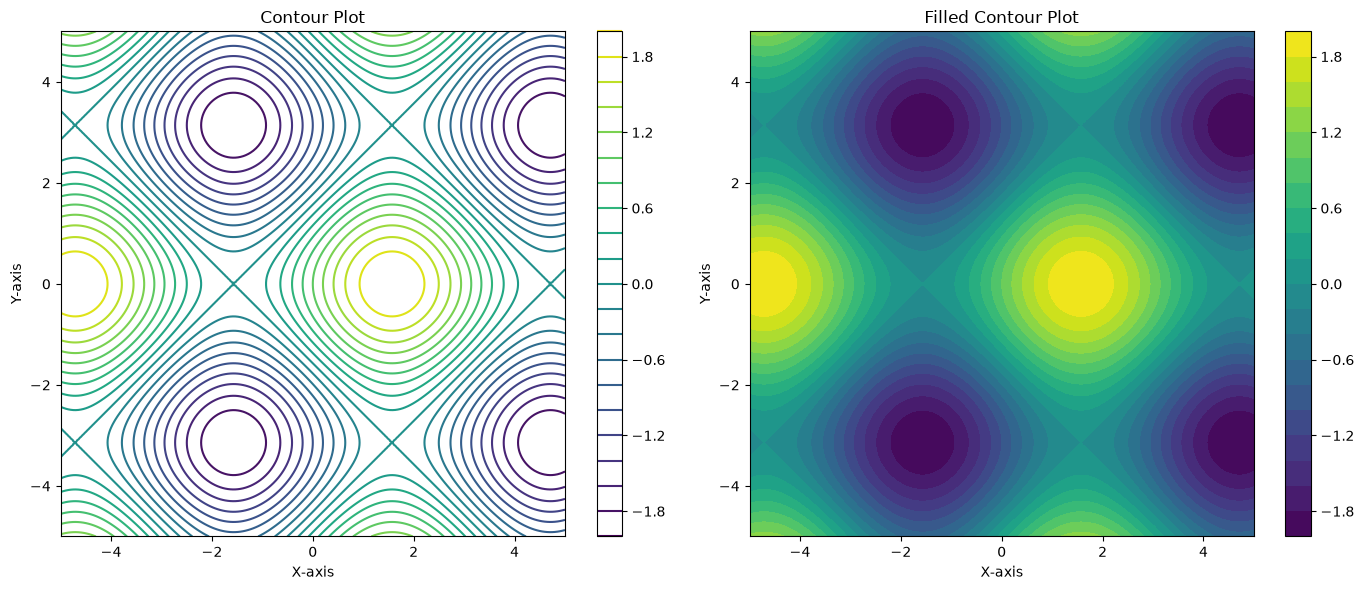

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

contour = ax[0].contour(
    X,
    Y,
    Z,
    levels=20,
    cmap="viridis"
)
ax[0].set_title("Contour Plot")
ax[0].set_xlabel("X-axis")
ax[0].set_ylabel("Y-axis")

fig.colorbar(contour, ax=ax[0])

filled = ax[1].contourf(
    X,
    Y,
    Z,
    levels=20,
    cmap="viridis"
)

ax[1].set_title("Filled Contour Plot")
ax[1].set_xlabel("X-axis")
ax[1].set_ylabel("Y-axis")

fig.colorbar(filled, ax=ax[1])

plt.tight_layout()
plt.show()

# Concepts Covered

After completing these questions, you should be comfortable with

- ✅ Colored Scatter Plots
- ✅ Alpha Transparency
- ✅ Figure Size Customization
- ✅ Annotating Graphs
- ✅ Horizontal & Vertical Reference Lines
- ✅ Bubble Charts
- ✅ Subplots using `plt.subplots()`
- ✅ Subplots using `fig.add_subplot()`
- ✅ Shared Axes
- ✅ 3D Scatter Plots
- ✅ 3D Line Plots
- ✅ 3D Surface Plots
- ✅ Contour Plots
- ✅ Filled Contour Plots
- ✅ Choosing the Appropriate Visualization
- ✅ Multi-Plot Dashboard Creation